In [7]:
from pyexpat import features
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle


In [8]:
model=Sequential()
model.add(Dense(512,activation='relu',input_dim=51200))
model.add(Dropout(0.3))
model.add(Dense(256,activation='relu',input_dim=51200))
model.add(Dropout(0.3))
model.add(Dense(128,activation='relu',input_dim=51200))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [9]:
with open('features.h5', 'rb') as f:
    features=pickle.load(f)
with open('labels.h5', 'rb') as f:
    labels=pickle.load(f)


In [10]:
with open('features_test.h5', 'rb') as f:
    features_test=pickle.load(f)
with open('labels_test.h5', 'rb') as f:
    labels_test=pickle.load(f)

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │    26,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,379,265 (100.63 MB)

 Trainable params: 26,379,265 (100.63 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history=model.fit(features,labels,epochs=30,batch_size=50,validation_data=(features_test,labels_test))

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.5105 - loss: 1.1593 - val_accuracy: 0.5000 - val_loss: 0.6894
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.5070 - loss: 0.7446 - val_accuracy: 0.5229 - val_loss: 0.6867
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.5440 - loss: 0.6969 - val_accuracy: 0.5864 - val_loss: 0.6781
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.5760 - loss: 0.6816 - val_accuracy: 0.5586 - val_loss: 0.6772
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.5690 - loss: 0.6824 - val_accuracy: 0.5750 - val_loss: 0.6803
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.5825 - loss: 0.6740 - val_accuracy: 0.5964 - val_loss: 0.6598
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.5970 - loss: 0.6636 - val_accuracy: 0.6257 - val_loss: 0.6753
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.5835 - loss: 0.6720 - val_accuracy: 0.5050 

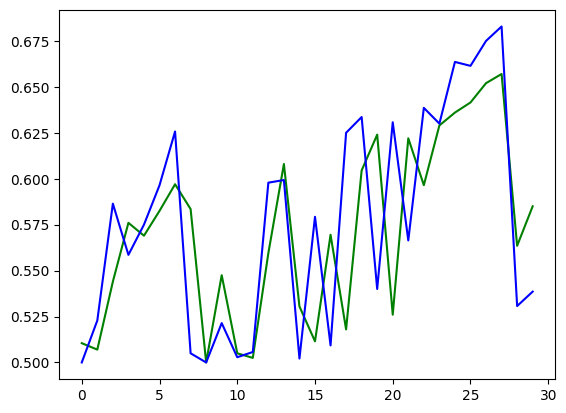

In [13]:
import matplotlib.pyplot as plt
epach=range(30)
plt.plot(epach,history.history['accuracy'] ,color='green')
plt.plot(epach,history.history['val_accuracy'] ,color='blue')